# Data verification and features Notebook

**Purpose.** Check that the input file is the one analysed in the report, reproduce the values published by Renaud et al. (2022), compute the 14 fragmentomic features, and test whether the capture sheet is in the same sample order as the sWGS sheet.

**Input:** `data/elife-71569-supp1-v2.xlsx` (Supplementary File 1, version 2).
**Outputs:** `results/features_wgs.csv`, `results/features_capture.csv`, `figures/fig4_1_profiles.png`.
**Report sections:** 3.2 (Table 3.1), 3.4 (Table 3.2), 4.1, 4.4 (pairing test), Figure 4.1.

In [1]:
# ---- Setup: imports, run mode and folders --------------------------------------------
import os, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.exceptions import ConvergenceWarning

import common, engine
from common import load, feature_matrix, sha256, logit, expit, LENGTHS, EXPECTED_SHA256
from engine import splits, fit_predict, pooled_metrics, nb_corrected_t

# Elastic-net fits at the weakest penalties on the path can stop before full convergence;
# this is expected and does not affect the selected model, so these warnings are hidden.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
# openpyxl warns about an Excel extension it cannot read; it does not affect the data.
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

# Output folders: tables and cached results in results/, figures in figures/
RES = Path("results")
FIG = Path("figures")
RES.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
DATA = Path("data/elife-71569-supp1-v2.xlsx")

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
print("Repeats:", engine.N_REPEATS, "| random-forest trees:", engine.RF_TREES)

C:\Users\5320\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Repeats: 20 | random-forest trees: 500


## 1. Verify the input file

The checksum confirms that this is exactly the file analysed in the report. The integrity checks look for anything that would make the fragment counts untrustworthy: missing or negative values, non-integer counts, or duplicated samples.

In [2]:
digest = sha256(DATA)
print("SHA-256:", digest)
assert digest == EXPECTED_SHA256, "Not the analysed file: expected version 2 of Supplementary File 1."

D = load(DATA)
w, c = D["frag_wgs"], D["frag_cap"]
ichor, vaf, m = D["ichor"], D["vaf"], D["labelled"]
print("sWGS counts:", w.shape, "| capture counts:", c.shape)

for name, X in [("sWGS", w), ("capture", c)]:
    print(f"{name}: missing={np.isnan(X).sum()}, negative={(X < 0).sum()}, "
          f"non-integer={(X % 1 != 0).sum()}, duplicate rows={pd.DataFrame(X).duplicated().sum()}")

print("Fragments per sWGS sample: %.1f-%.1f million" % (w.sum(1).min() / 1e6, w.sum(1).max() / 1e6))
mode_w, mode_c = LENGTHS[w.argmax(1)], LENGTHS[c.argmax(1)]
print("Modal length - sWGS: %d-%d bp (median %d); capture: %d-%d bp (median %d)"
      % (mode_w.min(), mode_w.max(), np.median(mode_w), mode_c.min(), mode_c.max(), np.median(mode_c)))

SHA-256: f0693eee0b6b2c0ddcdcfd609ba9ab087828db73313a135b05afb4859c4698e6
sWGS counts: (142, 671) | capture counts: (86, 671)
sWGS: missing=0, negative=0, non-integer=0, duplicate rows=0
capture: missing=0, negative=0, non-integer=0, duplicate rows=0
Fragments per sWGS sample: 5.1-14.1 million
Modal length - sWGS: 164-167 bp (median 165); capture: 165-181 bp (median 176)


## 2. Reproduce the published values (Table 3.1)

If these match the paper, the file has been parsed correctly: in particular, the correct columns hold the ichorCNA and VAF-based estimates.

In [3]:
t21 = pd.DataFrame([
    ["Samples in the sWGS and capture sheets", f"{w.shape[0]} and {c.shape[0]}", "142 and 86"],
    ["Samples with a VAF-based ctDNA fraction", int(m.sum()), "86"],
    ["VAF-based fraction: minimum, median, maximum",
     ", ".join(f"{v:.3f}" for v in (vaf[m].min(), np.median(vaf[m]), vaf[m].max())), "0.009, 0.197, 0.895"],
    ["ichorCNA estimate: minimum, median, maximum (142 samples)",
     ", ".join(f"{v:.3f}" for v in (ichor.min(), np.median(ichor), ichor.max())), "0.030, 0.071, 0.728"],
    ["Pearson correlation, ichorCNA with VAF-based fraction", f"{pearsonr(ichor[m], vaf[m])[0]:.3f}", "0.79"],
], columns=["Check", "This notebook", "Renaud et al. (2022)"])
display(t21)

q1, q3 = np.percentile(vaf[m], [25, 75])
print(f"Analysis cohort: n = {m.sum()}, median VAF-based fraction {np.median(vaf[m]):.1%} "
      f"(IQR {q1:.1%}-{q3:.1%})")
print("Samples below 2%, 5% and 10%:", [int((vaf[m] < t).sum()) for t in (0.02, 0.05, 0.10)])
print("At the ichorCNA floor of 0.03 - analysed:", int((ichor[m] == 0.03).sum()),
      "| excluded:", int((ichor[~m] == 0.03).sum()), "of", int((~m).sum()))
print("ichorCNA below the VAF-based value in %.0f%% of analysed samples" % (100 * (ichor[m] < vaf[m]).mean()))

,Check,This notebook,Renaud et al. (2022)
0,Samples in the sWGS and capture sheets,142 and 86,142 and 86
1,Samples with a VAF-based ctDNA fraction,86,86
2,"VAF-based fraction: minimum, median, maximum","0.009, 0.197, 0.895","0.009, 0.197, 0.895"
3,"ichorCNA estimate: minimum, median, maximum (1...","0.030, 0.072, 0.728","0.030, 0.071, 0.728"
4,"Pearson correlation, ichorCNA with VAF-based f...",0.790,0.79


Analysis cohort: n = 86, median VAF-based fraction 19.7% (IQR 9.8%-53.5%)
Samples below 2%, 5% and 10%: [1, 8, 23]
At the ichorCNA floor of 0.03 - analysed: 4 | excluded: 52 of 56
ichorCNA below the VAF-based value in 69% of analysed samples


## 3. Compute the 14 fragmentomic features (Table 3.2)

Counts are converted to densities inside `features_one`, so sequencing depth cannot act as a signal. No feature is selected or tuned using the outcome; the correlations below are descriptive only (Section 4.1).

In [4]:
Xw, Xc = feature_matrix(w), feature_matrix(c)
feat_cols = list(Xw.columns)
out_w = Xw.copy()
out_w.insert(0, "ichorCNA", ichor)
out_w.insert(1, "vaf_ctdna", vaf)
out_w.to_csv(RES / "features_wgs.csv", index=False)
Xc.to_csv(RES / "features_capture.csv", index=False)
display(Xw.describe().T[["mean", "std", "min", "max"]].round(4))

,mean,std,min,max
short_long_ratio,0.2833,0.1124,0.1647,0.7920
sub_nucleosomal_frac,0.2024,0.0521,0.1271,0.4188
mono_peak_pos,165.4789,0.5677,164.0000,167.0000
mono_peak_height,0.0250,0.0031,0.0135,0.0336
mono_peak_fwhm,24.8803,4.6501,19.0000,52.0000
di_mono_ratio,0.0925,0.0386,0.0402,0.2728
periodicity_10bp,3.7075,0.4096,2.3794,5.5648
entropy,7.1864,0.2237,6.6444,7.8163
mean_length,183.1299,8.4765,163.6939,210.6954
sd_length,68.5490,9.2909,48.6879,98.0690


In [5]:
# Section 4.1: association with the outcome, redundancy, and the near-discrete peak position
L = out_w[m]
rho = pd.Series({f: spearmanr(L[f], L.vaf_ctdna)[0] for f in feat_cols}).sort_values(key=abs, ascending=False)
display(rho.round(2).to_frame("Spearman rho with VAF-based fraction"))

C = L[feat_cols].corr(method="spearman").abs()
pairs = [(a, b, round(C.loc[a, b], 2)) for i, a in enumerate(feat_cols) for b in feat_cols[i + 1:] if C.loc[a, b] > 0.9]
print(len(pairs), "feature pairs with |rho| > 0.9:", pairs)
print("Peak position values across all 142 samples:", Xw.mono_peak_pos.value_counts().to_dict())
print("Correlation with ichorCNA itself:",
      {f: round(spearmanr(L[f], L.ichorCNA)[0], 2) for f in ["short_long_ratio", "di_mono_ratio"]})

,Spearman rho with VAF-based fraction
short_long_ratio,0.64
di_mono_ratio,0.59
kurtosis,-0.52
iqr_length,0.51
entropy,0.48
skewness,-0.47
sub_nucleosomal_frac,0.46
sd_length,0.44
mono_peak_height,-0.43
mono_peak_fwhm,0.38


10 feature pairs with |rho| > 0.9: [('short_long_ratio', 'sub_nucleosomal_frac', np.float64(0.93)), ('mono_peak_height', 'entropy', np.float64(0.91)), ('mono_peak_height', 'iqr_length', np.float64(0.94)), ('di_mono_ratio', 'sd_length', np.float64(0.92)), ('di_mono_ratio', 'kurtosis', np.float64(0.97)), ('entropy', 'skewness', np.float64(0.91)), ('entropy', 'kurtosis', np.float64(0.92)), ('entropy', 'iqr_length', np.float64(0.97)), ('sd_length', 'kurtosis', np.float64(0.93)), ('skewness', 'kurtosis', np.float64(0.93))]
Peak position values across all 142 samples: {165.0: 70, 166.0: 67, 164.0: 3, 167.0: 2}
Correlation with ichorCNA itself: {'short_long_ratio': np.float64(0.59), 'di_mono_ratio': np.float64(0.61)}


## 4. Test the capture-to-sWGS pairing 

The file has no identifiers, so Analysis 3 assumes that capture row *k* is the *k*-th sWGS sample with a VAF value. If that is true, the same feature measured on the two platforms should correlate strongly, far more than under random re-orderings of the capture rows. The alternative ordering (the first 86 sWGS rows) is a negative control.

In [6]:
rng = np.random.default_rng(1)
n_perm = 2000
Wl = L[feat_cols].reset_index(drop=True)
six = ["short_long_ratio", "di_mono_ratio", "sub_nucleosomal_frac", "median_length", "kurtosis", "entropy"]
rows = []
for f in six:
    r = spearmanr(Wl[f], Xc[f])[0]
    null = np.array([spearmanr(Wl[f], rng.permutation(Xc[f].values))[0] for _ in range(n_perm)])
    rows.append(dict(feature=f, rho_paired=r, permutation_p=(np.abs(null) >= abs(r)).mean(),
                     rho_capture_vs_VAF=spearmanr(Xc[f], L.vaf_ctdna)[0],
                     rho_sWGS_vs_VAF=spearmanr(Wl[f], L.vaf_ctdna)[0]))
display(pd.DataFrame(rows).round(3))
print(f"A permutation p of 0 means no permutation reached the observed value (p < 1/{n_perm}).")

alt = spearmanr(out_w.short_long_ratio.iloc[:86], Xc.short_long_ratio)[0]
print(f"Negative control - first 86 sWGS rows: rho = {alt:.3f}")

from sklearn.preprocessing import StandardScaler
Zw, Zc = StandardScaler().fit_transform(Wl[six]), StandardScaler().fit_transform(Xc[six])
dist = ((Zc[:, None, :] - Zw[None, :, :]) ** 2).sum(-1)
rank = np.array([(dist[k] < dist[k, k]).sum() for k in range(len(Zc))])
print("Presumed partner is the closest sWGS profile for", int((rank == 0).sum()),
      "of 86 capture profiles; median rank", np.median(rank))

,feature,rho_paired,permutation_p,rho_capture_vs_VAF,rho_sWGS_vs_VAF
0,short_long_ratio,0.917,0.0,0.584,0.645
1,di_mono_ratio,0.868,0.0,0.587,0.588
2,sub_nucleosomal_frac,0.822,0.0,0.298,0.456
3,median_length,0.487,0.0,0.369,-0.247
4,kurtosis,0.840,0.0,-0.513,-0.524
5,entropy,0.865,0.0,0.594,0.485


A permutation p of 0 means no permutation reached the observed value (p < 1/2000).
Negative control - first 86 sWGS rows: rho = 0.089
Presumed partner is the closest sWGS profile for 20 of 86 capture profiles; median rank 4.0


## 5. Fragment-length profiles

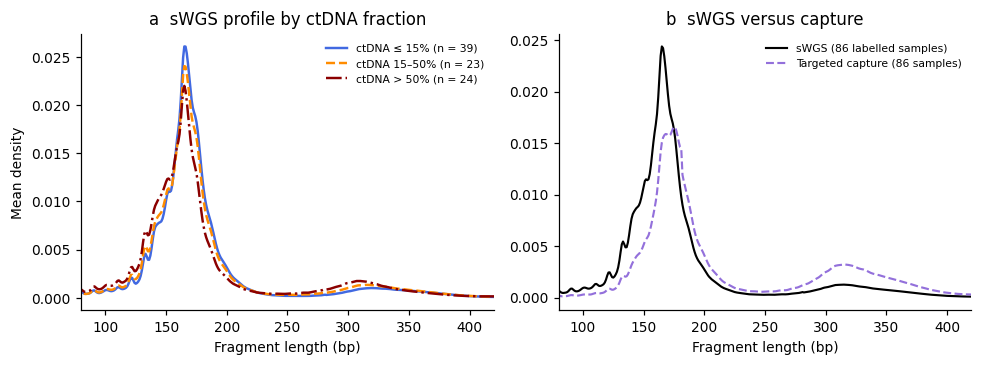

In [7]:
Wd, Cd = w / w.sum(1, keepdims=True), c / c.sum(1, keepdims=True)
vv = np.where(m, vaf, -1.0)            # unlabelled samples never fall inside a band

# Each ctDNA band gets its own colour AND line style, so the curves stay distinguishable
# where they overlap (and when the report is printed in black and white).
bands = [(0.00, 0.15, "royalblue",  "-",  "ctDNA \u2264 15%"),
         (0.15, 0.50, "darkorange", "--", "ctDNA 15\u201350%"),
         (0.50, 1.00, "darkred",    "-.", "ctDNA > 50%")]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for lo, hi, colour, style, name in bands:
    s = m & (vv > lo) & (vv <= hi)
    ax[0].plot(LENGTHS, Wd[s].mean(0), color=colour, linestyle=style, linewidth=1.6,
               label=f"{name} (n = {s.sum()})")
ax[0].set(xlim=(80, 420), xlabel="Fragment length (bp)", ylabel="Mean density",
          title="a  sWGS profile by ctDNA fraction")
ax[0].legend(frameon=False, fontsize=7)

ax[1].plot(LENGTHS, Wd[m].mean(0), color="black", linewidth=1.4, label="sWGS (86 labelled samples)")
ax[1].plot(LENGTHS, Cd.mean(0), color="mediumpurple", linestyle="--", linewidth=1.4,
           label="Targeted capture (86 samples)")
ax[1].set(xlim=(80, 420), xlabel="Fragment length (bp)", title="b  sWGS versus capture")
ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "fig4_1_profiles.png", dpi=150); plt.show()